# **1. Perkenalan Dataset**

**Nama Siswa**: Bryan Dewa Wicaksana  
**Proyek**: Membangun Sistem Machine Learning (MSML) - Submission  
**Dataset**: Heart Disease Prediction Dataset (UCI Machine Learning Repository / Kaggle)  

### **Deskripsi & Latar Belakang**
Penyakit jantung (Heart Disease) merupakan salah satu penyebab kematian tertinggi di dunia. Eksperimen ini bertujuan untuk mengolah data medis klinis pasien guna membangun model Machine Learning yang mampu mengklasifikasikan apakah seorang pasien berisiko mengidap penyakit jantung (`target = 1`) atau tidak (`target = 0`).

### **Keterangan Fitur Dataset:**
1. `age`: Usia pasien (tahun)
2. `sex`: Jenis kelamin (1 = Laki-laki, 0 = Perempuan)
3. `cp`: Tipe nyeri dada / Chest Pain (0: Typical Angina, 1: Atypical Angina, 2: Non-anginal Pain, 3: Asymptomatic)
4. `trestbps`: Tekanan darah istirahat (mm Hg saat masuk rumah sakit)
5. `chol`: Kolesterol serum (mg/dl)
6. `fbs`: Gula darah puasa > 120 mg/dl (1 = true; 0 = false)
7. `restecg`: Hasil elektrokardiografi istirahat (0, 1, 2)
8. `thalach`: Detak jantung maksimum yang dicapai
9. `exang`: Angina yang diinduksi olahraga (1 = ya; 0 = tidak)
10. `oldpeak`: Depresi ST yang diinduksi oleh olahraga relatif terhadap istirahat
11. `slope`: Kemiringan segmen ST olahraga puncak
12. `ca`: Jumlah pembuluh darah utama (0-3) yang diwarnai dengan fluorosopi
13. `thal`: Hasil thalassemia (1 = normal; 2 = fixed defect; 3 = reversable defect)
14. `target`: Diagnosis penyakit jantung (0 = Sehat, 1 = Memiliki Penyakit Jantung)

# **2. Import Library**

Pada tahap ini, kita mengimpor seluruh pustaka Python yang dibutuhkan untuk analisis data, visualisasi, preprocessing, dan pemodelan machine learning.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Konfigurasi grafik
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('muted')
print('[INFO] Seluruh pustaka berhasil diimpor!')

[INFO] Seluruh pustaka berhasil diimpor!


# **3. Memuat Dataset**

Memuat data mentah (`heart_raw.csv`) ke dalam DataFrame Pandas dan melakukan verifikasi struktur data awal.

In [2]:
def get_raw_file():
    for p in ['heart_raw.csv', '../dataset_raw/heart_raw.csv', 'dataset_raw/heart_raw.csv']:
        if os.path.exists(p):
            return p
    return 'heart_raw.csv'

raw_path = get_raw_file()
df_raw = pd.read_csv(raw_path)
print(f'=== 5 Baris Pertama Dataset ({raw_path}) ===')
display(df_raw.head())

print('\n=== Informasi Struktur Dataset ===')
df_raw.info()

print('\n=== Statistik Deskriptif Fitur ===')
display(df_raw.describe())

=== 5 Baris Pertama Dataset (../dataset_raw/heart_raw.csv) ===


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0



=== Informasi Struktur Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(3), int64(11)
memory usage: 33.3 KB

=== Statistik Deskriptif Fitur ===


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.458746
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,0.499120
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,1.000000


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, kita menganalisis karakteristik dataset, distribusi variabel target, hubungan antar fitur, serta pendeteksian pencilan (outliers).

/tmp/ipykernel_82918/2993740818.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df_raw, ax=axes[0], palette=['#2ecc71', '#e74c3c'])
/tmp/ipykernel_82918/2993740818.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(['Sehat (0)', 'Sakit (1)'])


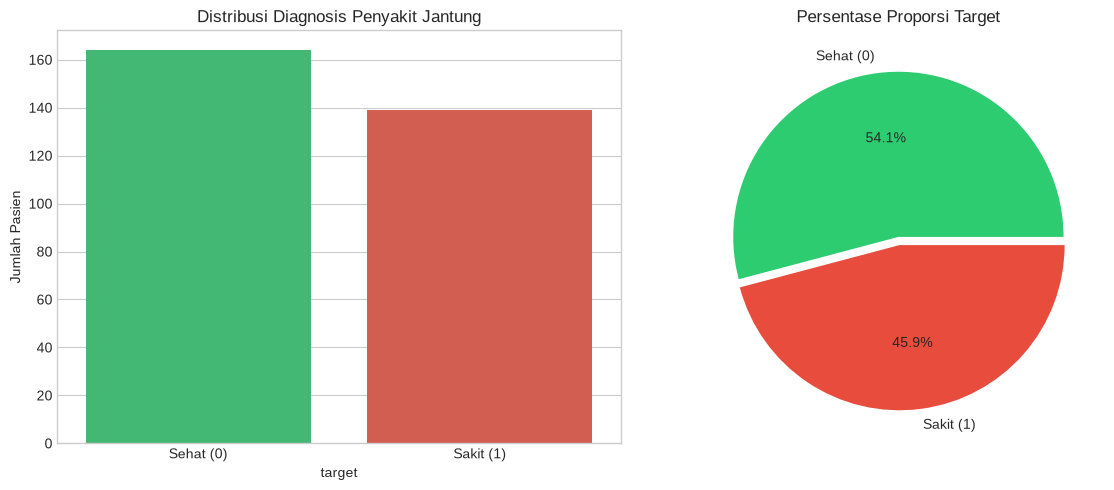

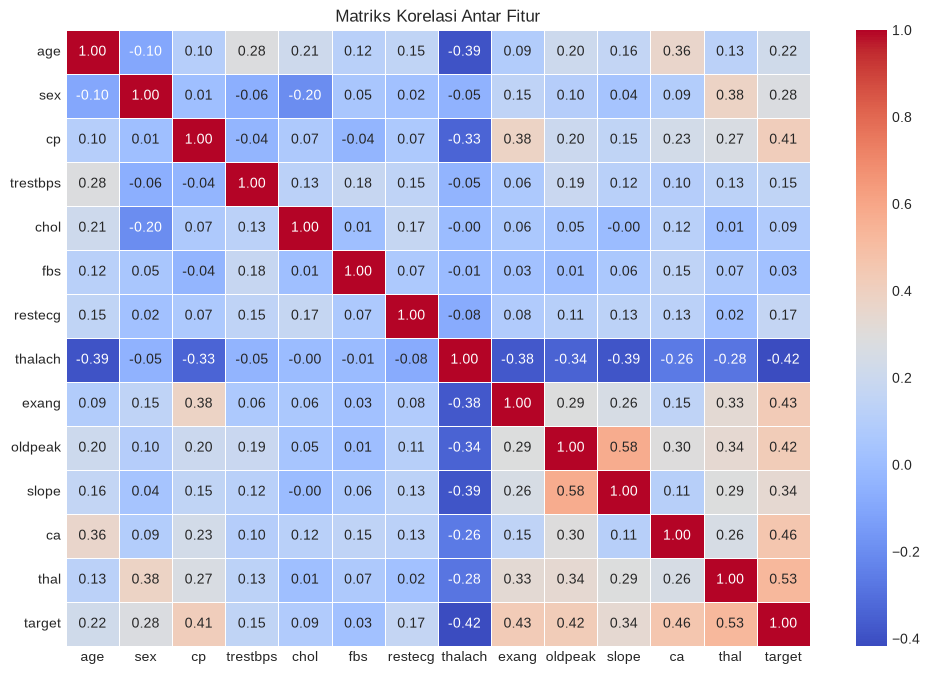

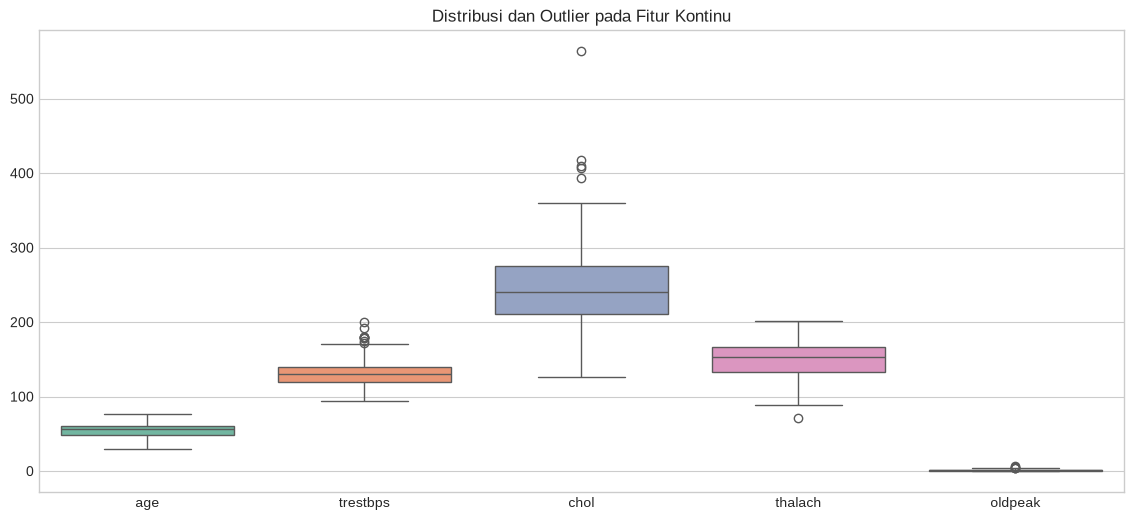

In [3]:
# 1. Visualisasi Distribusi Target
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(x='target', data=df_raw, ax=axes[0], palette=['#2ecc71', '#e74c3c'])
axes[0].set_title('Distribusi Diagnosis Penyakit Jantung')
axes[0].set_xticklabels(['Sehat (0)', 'Sakit (1)'])
axes[0].set_ylabel('Jumlah Pasien')

df_raw['target'].value_counts().plot.pie(autopct='%1.1f%%', ax=axes[1], colors=['#2ecc71', '#e74c3c'], labels=['Sehat (0)', 'Sakit (1)'], explode=[0, 0.05])
axes[1].set_title('Persentase Proporsi Target')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

# 2. Correlation Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df_raw.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriks Korelasi Antar Fitur')
plt.show()

# 3. Boxplot Deteksi Outlier Fitur Numerik
num_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
plt.figure(figsize=(14, 6))
sns.boxplot(data=df_raw[num_cols], palette='Set2')
plt.title('Distribusi dan Outlier pada Fitur Kontinu')
plt.show()

# **5. Data Preprocessing**

Tahap preprocessing meliputi:
1. **Pembersihan Data**: Penanganan nilai hilang (missing values) dan duplikat.
2. **Feature Scaling**: Standarisasi fitur kontinu (`StandardScaler`).
3. **Pemisahan Data**: Pembagian data latih (80%) dan data uji (20%).
4. **Penyimpanan Processed Dataset**: Menyimpan hasil preprocessing.

In [4]:
# 1. Cek Missing Values & Duplikat
print('Jumlah missing value per kolom:')
print(df_raw.isnull().sum())
print('Jumlah duplikat:', df_raw.duplicated().sum())

# Imputasi missing values jika ada
df_clean = df_raw.copy()
for col in df_clean.columns:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# 2. Scaling Fitur Kontinu
X = df_clean.drop(columns=['target'])
y = df_clean['target']

scaler = StandardScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])

# Gabungkan kembali
df_processed = pd.concat([X, y.reset_index(drop=True)], axis=1)
out_csv = 'dataset_preprocessing/heart_processed.csv' if os.path.exists('dataset_preprocessing') else 'heart_processed.csv'
df_processed.to_csv(out_csv, index=False)
print(f'\n[SUCCESS] Preprocessing selesai. Processed dataset disimpan ke {out_csv}')
display(df_processed.head())

# 3. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f'Bentuk X_train: {X_train.shape}, X_test: {X_test.shape}')

Jumlah missing value per kolom:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64
Jumlah duplikat: 0

[SUCCESS] Preprocessing selesai. Processed dataset disimpan ke dataset_preprocessing/heart_processed.csv


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,0.948726,1,1,0.757525,-0.264900,1,2,0.017197,0,1.087338,3,0.0,6.0,0
1,1.392002,1,4,1.611220,0.760415,0,2,-1.821905,1,0.397182,2,3.0,3.0,1
2,1.392002,1,4,-0.665300,-0.342283,0,2,-0.902354,1,1.346147,2,2.0,7.0,1
3,-1.932564,1,3,-0.096170,0.063974,0,0,1.637359,0,2.122573,3,0.0,3.0,0
4,-1.489288,0,2,-0.096170,-0.825922,0,2,0.980537,0,0.310912,1,0.0,3.0,0


Bentuk X_train: (242, 13), X_test: (61, 13)


# **6. Eksperimen Pelatihan Model Baseline**

Melatih model awal (Random Forest Classifier) pada dataset terproses untuk mengukur performa baseline.

In [5]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f'Akurasi Baseline Random Forest: {acc:.4f} ({acc*100:.2f}%)\n')
print('=== Classification Report ===')
print(classification_report(y_test, y_pred, target_names=['Sehat', 'Sakit']))

Akurasi Baseline Random Forest: 0.9016 (90.16%)

=== Classification Report ===
              precision    recall  f1-score   support

       Sehat       0.97      0.85      0.90        33
       Sakit       0.84      0.96      0.90        28

    accuracy                           0.90        61
   macro avg       0.90      0.91      0.90        61
weighted avg       0.91      0.90      0.90        61

